##Atividade Prática 3 - Esther de Oliveira

Garimpo e Diagnóstico de Dados de Saúde - SISAGUA

Inicialmente eu havia escolhido o Sistema de Informações sobre Nascidos Vivos (SINASC), mas durante os testes a API retornou a base vazia. Por isso, troquei o dataset para o SISAGUA - População Abastecida. Antes da troca, conferi a lista dos colegas e verifiquei que ninguém havia escolhido esse tema.

In [ ]:
# Instalação e importação de dependências
# pandas: usado para criar e analisar tabelas de dados.
# requests: usado para fazer a requisição na API.
# matplotlib e seaborn: usados para criar gráficos.
!pip install pandas requests matplotlib seaborn -q

# Importando as bibliotecas que serão usadas no notebook.
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos.
sns.set_theme(style="whitegrid")

# Configuração para o Pandas mostrar todas as colunas da tabela.
pd.set_option('display.max_columns', None)

Para o desafio de segurança, utilizei o gerenciador de Secrets do Google Colab. A autenticação é feita de forma segura através de uma chave (token) armazenada no ambiente isolado, evitando a exposição de credenciais sensíveis diretamente nas células de código (hardcoded).

In [ ]:
from google.colab import userdata

print("--- Configurando Credenciais ---")
# Puxando o token de forma segura através do ambiente do Colab
try:
    API_KEY = userdata.get('API_KEY')
    print("Token carregado com sucesso via Colab Secrets.")
except Exception as e:
    print("Aviso: Não foi possível carregar a API_KEY. Verifique as configurações na aba Secrets.")

--- Configurando Credenciais ---
Token carregado com sucesso via Colab Secrets.


O dataset escolhido foi o SISAGUA - População Abastecida. Ele reúne informações relacionadas ao abastecimento de água para consumo humano, como município, forma de abastecimento, população urbana, população rural e outras características do sistema de abastecimento.

In [ ]:
# Link do portal Dados Abertos do SUS
LINK_DATASET = "https://dadosabertos.saude.gov.br/"

# Endpoint da API do SISAGUA - População Abastecida.
# Endpoint é o endereço específico da API usado para buscar os dados.
URL_DADOS = "https://apidadosabertos.saude.gov.br/sisagua/populacao-abastecida"

# Eu informo que quero receber JSON e envio a chave da API.
headers = {
    "accept": "application/json",
    "chave-api-dados": API_KEY
}

# limit define quantos registros serão trazidos.
# offset indica a página inicial da consulta.
params = {
    "limit": 1000,
    "offset": 0
}

Nesta etapa, realizei a requisição para a API, transformei a resposta em JSON e depois converti os registros em um DataFrame do Pandas para iniciar a exploração dos dados.

In [ ]:
# Fazendo a requisição para a API.
# Essa linha pede os dados para o servidor do DataSUS.
response = requests.get(URL_DADOS, headers=headers, params=params, timeout=90)

# Transformando a resposta da API em JSON.
# JSON é o formato usado pela API para devolver os dados.
dados_json = response.json()

# Mostrando as chaves principais da resposta.
# Isso ajuda a entender onde os registros estão guardados.
print("Chaves encontradas na resposta:", list(dados_json.keys()))

# No endpoint do SISAGUA, os registros ficam dentro da chave sisagua_populacao_abastecida.
registros = dados_json["sisagua_populacao_abastecida"]

# Criando o DataFrame.
# DataFrame é a tabela do Pandas usada para analisar os dados.
df = pd.DataFrame(registros)

print("Quantidade de linhas carregadas:", df.shape[0])
print("Quantidade de colunas carregadas:", df.shape[1])

# Mostrando as cinco primeiras linhas para conferir se a base carregou corretamente.
df.head()

Chaves encontradas na resposta: ['sisagua_populacao_abastecida']
Quantidade de linhas carregadas: 1000
Quantidade de colunas carregadas: 37


,filtracao,numero_de_economias_residenciais_domicilios_permanentes,populacao_rural,cisterna,codigo_forma_de_abastecimento,caixa_dagua,pop_recebe_agua_de_saa,carro_pipa,regiao_geografica,numero_de_economias_residenciais_de_uso_ocasional,nome_da_forma_de_abastecimento,chafariz,regional_de_saude,data_de_preenchimento,tipo_da_forma_de_abastecimento,codigo_ibge,outro_tipo_de_suprimento,desinfeccao,municipio,ano_de_referencia,pop_recebe_agua_de_saasac,fonte,sem_reservacao,captacao_de_agua_de_chuva,tipo_da_instituicao,nome_da_instituicao,sigla_da_instituicao,populacao_urbana,canalizacao,uf,nome_do_escritorio_regionallocal,cnpj_do_escritorio_regionallocal,data_de_registro_no_sisagua,captacao_superficial,captacao_subterranea,cnpj_da_instituicao,populacao_estimada
0,Sim,8880.0,None,,S270240000002,,,,NORDESTE,0.0,SAA DE DELMIRO GOUVEIA ADUTORA,,10 REGIÃO DEG AL,2014/02/18 00:00:00.000,SAA,270240,,Sim,DELMIRO GOUVEIA,2014,,,,,Regional,COMPANHIA DE SANEAMENTO DE ALAGOAS,CASAL,None,,AL,UNIDADE SERTAO DELMIRO GOUVEIA,12294708000181.0,2014/02/18 14:12:25.000,Sim,Não,12294708000181.0,32234
1,Sim,5510.0,None,,S431320000001,,,,SUL,0.0,NOVA PETRÓPOLIS,,5ª CRS,2014/03/26 00:00:00.000,SAA,431320,,Sim,NOVA PETROPOLIS,2014,,,,,Regional,COMPANHIA RIOGRANDENSE DE SANEAMENTO,CORSAN,None,,RS,SUPERINTENDENCIA REGIONAL NORDESTE SURNE,92802784036895.0,2014/03/26 15:36:12.000,Sim,Sim,92802784000190.0,15704
2,Sim,3270.0,None,,S431337000001,,,,SUL,0.0,NOVA SANTA RITA,,1ª CRS,2014/03/26 00:00:00.000,SAA,431337,,Sim,NOVA SANTA RITA,2014,,,,,Regional,COMPANHIA RIOGRANDENSE DE SANEAMENTO,CORSAN,None,,RS,SUPERINTENDENCIA REGIONAL SINOS SURSIN,92802784031150.0,2014/03/26 15:53:58.000,Sim,Não,92802784000190.0,10268
3,Sim,9336.0,None,,S430640000001,,,,SUL,0.0,DOIS IRMÃOS,,1ª CRS,2014/03/28 00:00:00.000,SAA,430640,,Sim,DOIS IRMAOS,2014,,,,,Regional,COMPANHIA RIOGRANDENSE DE SANEAMENTO,CORSAN,None,,RS,SUPERINTENDENCIA REGIONAL SINOS SURSIN,92802784031150.0,2014/03/28 13:10:33.000,Sim,Sim,92802784000190.0,27261
4,Sim,1116.0,None,,S430650000001,,,,SUL,0.0,DOM FELICIANO,,1ª CRS,2014/03/28 00:00:00.000,SAA,430650,,Sim,DOM FELICIANO,2014,,,,,Regional,COMPANHIA RIOGRANDENSE DE SANEAMENTO,CORSAN,None,,RS,SUPERINTENDENCIA REGIONAL SUL SURSUL,92802784036461.0,2014/03/28 13:38:31.000,Sim,Não,92802784000190.0,3448


Com a base carregada, fiz o diagnóstico inicial: tamanho da base, tipos das colunas, percentual de dados ausentes, duplicidade e possíveis inconsistências.

In [ ]:
# Estrutura básica
# Aqui verifico o tamanho da base: quantidade de linhas e colunas.
print("Linhas e colunas da base:")
print(df.shape)

# Tipos das variáveis.
# object geralmente indica texto. int e float indicam números.
print("\nTipos das variáveis:")
display(df.dtypes)

# Dados ausentes.
# Este cálculo mostra o percentual de valores vazios em cada coluna.
nulos = (df.isna().mean() * 100).round(2).sort_values(ascending=False)

print("\nPercentual de dados ausentes por coluna:")
display(nulos)

# Duplicidade.
# Aqui verifico se existem linhas exatamente iguais na base.
duplicados = df.duplicated().sum()
print("\nRegistros duplicados:", duplicados)

Linhas e colunas da base:
(1000, 37)

Tipos das variáveis:


,0
filtracao,object
numero_de_economias_residenciais_domicilios_permanentes,object
populacao_rural,object
cisterna,object
codigo_forma_de_abastecimento,object
caixa_dagua,object
pop_recebe_agua_de_saa,object
carro_pipa,object
regiao_geografica,object
numero_de_economias_residenciais_de_uso_ocasional,object



Percentual de dados ausentes por coluna:


,0
populacao_rural,99.8
populacao_urbana,99.8
numero_de_economias_residenciais_de_uso_ocasional,46.6
numero_de_economias_residenciais_domicilios_permanentes,0.9
filtracao,0.0
codigo_forma_de_abastecimento,0.0
cisterna,0.0
carro_pipa,0.0
caixa_dagua,0.0
regiao_geografica,0.0



Registros duplicados: 0


Também verifiquei algumas colunas importantes da base, como município, UF, população urbana, população rural e tipo de forma de abastecimento.

In [ ]:
# A lista abaixo tem os campos que ajudam a interpretar o abastecimento de água.
colunas_importantes = [
    'uf', 'municipio', 'codigo_ibge', 'tipo_da_forma_de_abastecimento',
    'nome_da_forma_de_abastecimento', 'populacao_urbana', 'populacao_rural'
]

# Para cada coluna importante, eu mostro os valores mais frequentes.
for coluna in colunas_importantes:
    if coluna in df.columns:
        print("\nColuna:", coluna)
        display(df[coluna].value_counts(dropna=False).head(10))


Coluna: uf


,count
uf,
PR,270
RS,216
GO,98
SP,81
CE,77
BA,61
SE,55
AL,32
SC,25



Coluna: municipio


,count
municipio,
BELEM,7
GUARAPUAVA,5
MACEIO,5
ARACATI,5
CAMACARI,5
JAPARATUBA,5
LONDRINA,5
DIAS D'AVILA,5
FLORIANOPOLIS,4



Coluna: codigo_ibge


...

,count
nome_da_forma_de_abastecimento,
SIAA DE FEIRA DE SANTANA,8
ETA GILBERTO FREIRE,7
DESCOBERTO,7
ETA DELMIRO GOUVEIA,6
ETA MAMBU BRANCO,5
SOBRADINHO / PLANALTINA,4
ETA3,4
ETA CAJAIBA,4
SIAA DE RIACHÃO DO JACUÍPE,3



Coluna: populacao_urbana


,count
populacao_urbana,
None,998
2568,1
358,1



Coluna: populacao_rural


,count
populacao_rural,
None,998
0,2


Para visualizar melhor os dados ausentes, gerei um gráfico com as colunas que possuem maior percentual de valores nulos.

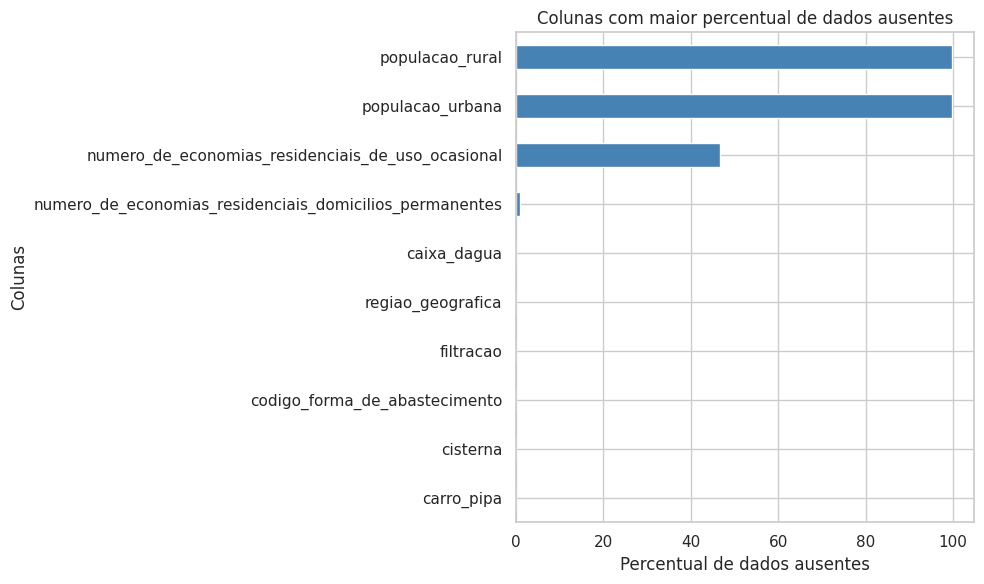

In [ ]:
# Gráfico das colunas com mais valores ausentes.
top_nulos = nulos.head(10).sort_values()

# Depois gero um gráfico de barras horizontal.
# Esse tipo de gráfico facilita comparar quais colunas têm mais problemas de preenchimento.
plt.figure(figsize=(10, 6))
top_nulos.plot(kind="barh", color="steelblue")
plt.title("Colunas com maior percentual de dados ausentes")
plt.xlabel("Percentual de dados ausentes")
plt.ylabel("Colunas")
plt.tight_layout()
plt.show()

## Resumão final

Nesta atividade, eu precisei trocar o dataset inicialmente escolhido. A primeira opção era o SINASC, mas durante os testes a API retornou a base vazia. Para não usar uma base repetida dos colegas e ainda cumprir a proposta da atividade, conferi a lista da turma e escolhi o **SISAGUA - População Abastecida**, que ainda não havia sido escolhido.

O SISAGUA é uma base relacionada ao abastecimento de água para consumo humano. Ela traz informações como município, UF, forma de abastecimento, população urbana, população rural e outras características ligadas ao sistema de abastecimento. A base foi acessada pela API do Dados Abertos do SUS usando uma chave armazenada no Google Colab Secrets, evitando deixar a chave exposta diretamente no código.

Na análise exploratória, primeiro verifiquei se a API respondeu corretamente. Depois transformei os dados em um DataFrame do Pandas para analisar a estrutura da base. Foram observados a quantidade de linhas e colunas, os tipos das variáveis, o percentual de dados ausentes, possíveis duplicidades e algumas colunas importantes para entender o conteúdo do dataset.

O diagnóstico mostra que a base é útil para análise, mas ainda precisa de limpeza antes de uma análise mais profunda. Isso acontece porque algumas colunas podem ter dados ausentes, existem campos categóricos que precisam ser interpretados com apoio do dicionário de dados e pode haver necessidade de padronizar nomes, códigos de municípios e tipos de abastecimento.

Portanto, minha conclusão é que a base do SISAGUA está adequada para uma exploração inicial, mas não está totalmente pronta para modelagem ou tomada de decisão sem tratamento. Antes de usar esses dados em uma análise final, seria importante limpar valores nulos, conferir duplicidades, entender o significado das categorias e consultar o dicionário de dados oficial.